In [1]:
import os

print("Current folder:")
print(os.getcwd())

print("\nFiles in current folder:")
print(os.listdir())

import os

print(os.listdir(".."))

Current folder:
c:\Users\LAKSHMI\OneDrive\Desktop\Customer-Churn-Prediction\dataset\notebook

Files in current folder:
['churn_analysis.ipynb', 'screenshot']
['notebook', 'Telco_Churn.csv']


In [2]:
import pandas as pd

df = pd.read_csv("../Telco_Churn.csv")

print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [3]:
# Dataset information
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
# Check missing values
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [5]:
print(df['Churn'].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [6]:
# Remove customerID column
df.drop('customerID', axis=1, inplace=True)

print("customerID removed")

customerID removed


In [7]:
print(df.dtypes)

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [8]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(df['TotalCharges'].dtype)

float64


In [9]:
print(df.isnull().sum())

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [10]:
df.dropna(inplace=True)

print("Null values removed")

Null values removed


In [11]:
print(df.info())

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   str    
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   str    
 3   Dependents        7032 non-null   str    
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   str    
 6   MultipleLines     7032 non-null   str    
 7   InternetService   7032 non-null   str    
 8   OnlineSecurity    7032 non-null   str    
 9   OnlineBackup      7032 non-null   str    
 10  DeviceProtection  7032 non-null   str    
 11  TechSupport       7032 non-null   str    
 12  StreamingTV       7032 non-null   str    
 13  StreamingMovies   7032 non-null   str    
 14  Contract          7032 non-null   str    
 15  PaperlessBilling  7032 non-null   str    
 16  PaymentMethod     7032 non-null   str    
 17  MonthlyChar

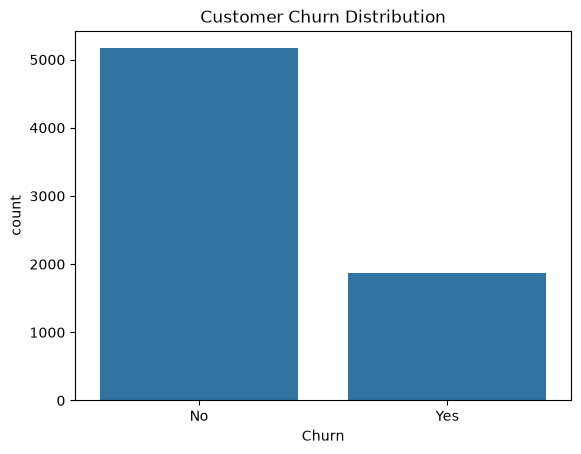

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x='Churn', data=df)

plt.title("Customer Churn Distribution")

plt.show()

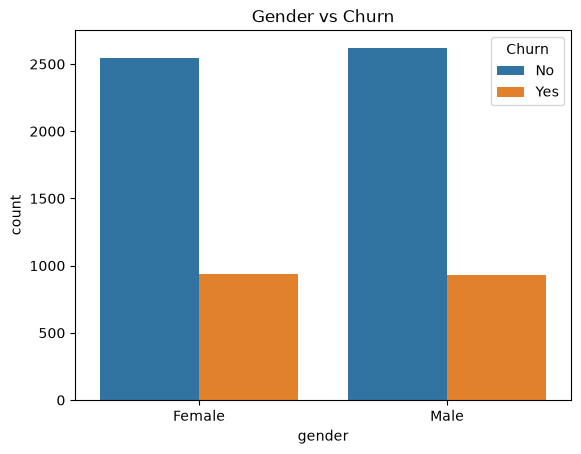

In [13]:

sns.countplot(x='gender', hue='Churn', data=df)

plt.title("Gender vs Churn")

plt.show()

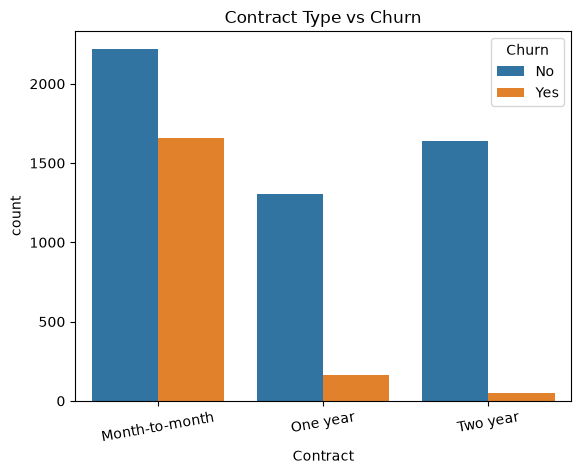

In [14]:
sns.countplot(x='Contract', hue='Churn', data=df)

plt.title("Contract Type vs Churn")

plt.xticks(rotation=10)

plt.show()

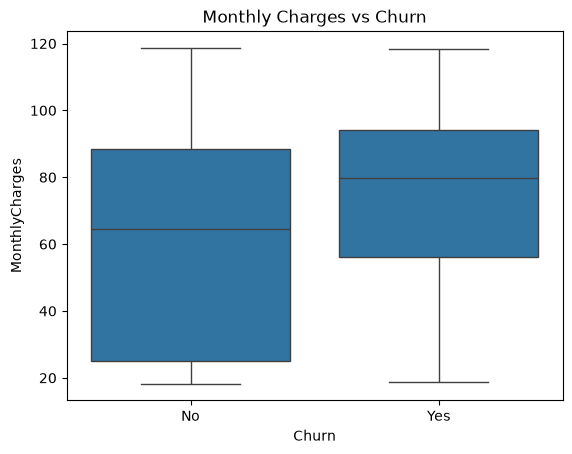

In [15]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

plt.title("Monthly Charges vs Churn")

plt.show()

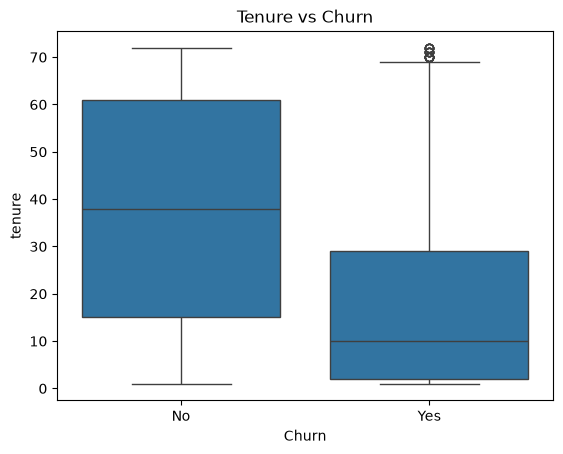

In [16]:
sns.boxplot(x='Churn', y='tenure', data=df)

plt.title("Tenure vs Churn")

plt.show()

In [17]:
# Convert categorical columns into numeric
df_encoded = pd.get_dummies(df, drop_first=True)

print(df_encoded.head())

   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
0              0       1           29.85         29.85        False   
1              0      34           56.95       1889.50         True   
2              0       2           53.85        108.15         True   
3              0      45           42.30       1840.75         True   
4              0       2           70.70        151.65        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  MultipleLines_Yes  ...  StreamingTV_Yes  \
0                            True              False  ...            False   
1                           False              False  ...            False   
2                         

In [18]:
# Features
X = df_encoded.drop('Churn_Yes', axis=1)

# Target
y = df_encoded['Churn_Yes']

print(X.shape)
print(y.shape)

(7032, 30)
(7032,)


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5625, 30)
Testing data: (1407, 30)


In [20]:
from sklearn.ensemble import RandomForestClassifier

# Create model
model = RandomForestClassifier()

# Train model
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [21]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[False False False False False False False  True False False]


In [22]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.7810945273631841


In [23]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[928 105]
 [203 171]]


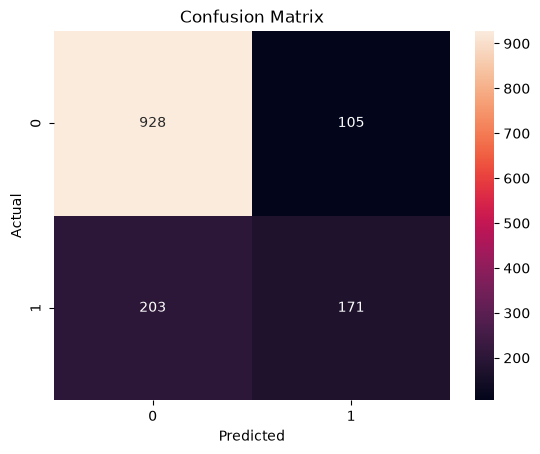

In [24]:
sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.82      0.90      0.86      1033
        True       0.62      0.46      0.53       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.69      1407
weighted avg       0.77      0.78      0.77      1407



In [26]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

                           Feature  Importance
3                     TotalCharges    0.192085
1                           tenure    0.169423
2                   MonthlyCharges    0.165723
10     InternetService_Fiber optic    0.045143
28  PaymentMethod_Electronic check    0.037765
25               Contract_Two year    0.031936
4                      gender_Male    0.028323
13              OnlineSecurity_Yes    0.025473
19                 TechSupport_Yes    0.025085
26            PaperlessBilling_Yes    0.024859


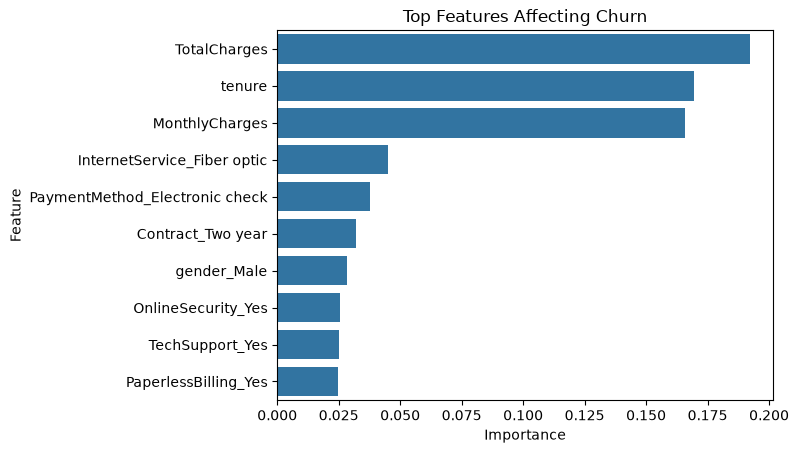

In [27]:
top_features = feature_importance.head(10)

sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features
)

plt.title("Top Features Affecting Churn")

plt.show()